# Tier 4 · Notebook 22 — Instruction Tuning & Evaluation

> **Goal:** turn a **base** model (which just *completes* text) into an **instruction-follower** (which *does what you ask*), and build an **evaluation harness** — because measuring an LLM honestly is the genuinely hard, under-appreciated part of the whole pipeline.

**Two ideas.**
1. **Instruction tuning** = supervised fine-tuning on `(instruction, response)` pairs across *many* tasks. A base model trained on raw text will happily continue "Write a poem about cats" with "...for my English homework" — it completes, it doesn't obey. Fine-tuning on demonstrations of *following instructions* teaches it to map an instruction to the intended response, and — remarkably — this **generalizes to unseen instructions**.
2. **Evaluation** is where most people (and papers) go wrong. Loss/perplexity doesn't measure helpfulness; benchmarks are gameable and leak into training data; results swing wildly with prompt formatting. A residency-level engineer is *skeptical of eval numbers by default* and knows why.

We demonstrate both in a controlled setting where we know the right answer, so we can actually *measure* whether instruction tuning worked — and expose how fragile eval is.


In [1]:
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

# a tiny "instruction-following" world: digit sequences + 3 tasks (copy, reverse, sort)
DIGITS = 10; Lin = 4
COPY, REV, SORT, SEP = 10, 11, 12, 13     # special tokens
VOCAB = 14
tasks = {"copy": COPY, "reverse": REV, "sort": SORT}
def apply_task(name, x):
    if name == "copy": return list(x)
    if name == "reverse": return list(x)[::-1]
    if name == "sort": return sorted(x)

def make_example(name, rng):
    x = list(rng.integers(0, DIGITS, Lin))
    y = apply_task(name, x)
    instr = tasks[name]
    return [instr] + x + [SEP] + y          # [INSTR] x1..x4 [SEP] y1..y4   (len 10)

print("world: instruction token + 4 input digits + SEP + 4 output digits")
print("example (reverse):", make_example("reverse", np.random.default_rng(0)))


world: instruction token + 4 input digits + SEP + 4 output digits
example (reverse): [11, 8, 6, 5, 2, 13, 2, 5, 6, 8]


## 0. A small GPT trained two ways

We reuse our decoder-only transformer. We train two models:
- **"Base"**: trained on **only the copy task** (a stand-in for narrow/generic pretraining) — it never learns that the instruction token *means* anything.
- **"Instruction-tuned"**: trained on **all three tasks**, so it must read the instruction token and behave accordingly.

Then we evaluate both on all three tasks by having them **generate** the output and checking exact match.


In [2]:
SEQ = 2*Lin + 2      # full sequence length
class Block(nn.Module):
    def __init__(s,d,h):
        super().__init__(); s.ln1=nn.LayerNorm(d); s.ln2=nn.LayerNorm(d); s.h,s.dk=h,d//h
        s.qkv=nn.Linear(d,3*d); s.proj=nn.Linear(d,d); s.mlp=nn.Sequential(nn.Linear(d,4*d),nn.GELU(),nn.Linear(4*d,d))
        s.register_buffer("m",torch.tril(torch.ones(SEQ,SEQ)).bool())
    def forward(s,x):
        B,T,C=x.shape; q,k,v=s.qkv(s.ln1(x)).split(C,2); sp=lambda t:t.view(B,T,s.h,s.dk).transpose(1,2)
        q,k,v=sp(q),sp(k),sp(v); a=(q@k.transpose(-2,-1))/s.dk**0.5
        a=a.masked_fill(~s.m[:T,:T],float("-inf")); x=x+s.proj((F.softmax(a,-1)@v).transpose(1,2).reshape(B,T,C))
        return x+s.mlp(s.ln2(x))
class GPT(nn.Module):
    def __init__(s,d=96,h=4,nl=3):
        super().__init__(); s.tok=nn.Embedding(VOCAB,d); s.pos=nn.Embedding(SEQ,d)
        s.blocks=nn.ModuleList([Block(d,h) for _ in range(nl)]); s.ln=nn.LayerNorm(d); s.head=nn.Linear(d,VOCAB)
    def forward(s,x):
        h=s.tok(x)+s.pos(torch.arange(x.size(1),device=x.device))
        for b in s.blocks: h=b(h)
        return s.head(s.ln(h))

def train_on(task_list, steps=2000):
    rng=np.random.default_rng(0); m=GPT().to(device); opt=torch.optim.AdamW(m.parameters(),3e-3)
    for _ in range(steps):
        batch=torch.tensor([make_example(rng.choice(task_list), rng) for _ in range(128)],device=device)
        logits=m(batch[:,:-1]); loss=F.cross_entropy(logits.reshape(-1,VOCAB), batch[:,1:].reshape(-1))
        opt.zero_grad(); loss.backward(); opt.step()
    return m

base = train_on(["copy"])                          # narrow: only copy
instruct = train_on(["copy","reverse","sort"])     # instruction-tuned: all tasks
print("trained base (copy-only) and instruction-tuned (all tasks) models")


trained base (copy-only) and instruction-tuned (all tasks) models


## 1. The eval harness

Evaluation means: give the model an instruction + input, let it **generate** the output tokens, and compare to the ground truth. We measure **exact-match accuracy** per task on held-out inputs. This is the honest way to eval a generative model — *run it and check the output*, not just look at its loss.


task         base (copy-only)  instruction-tuned


copy                     1.00               1.00


reverse                  0.01               1.00


sort                     0.08               1.00


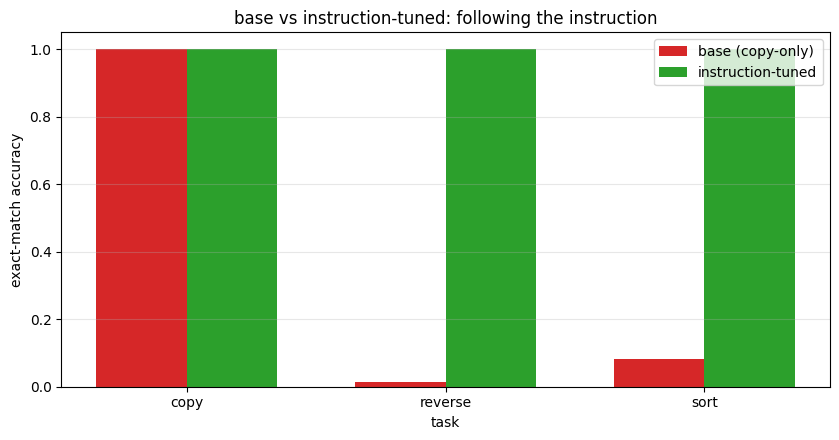

In [3]:
@torch.no_grad()
def evaluate(model, task, n=300, prefix=(), seed=123):
    rng=np.random.default_rng(seed); correct=0
    for _ in range(n):
        x=list(rng.integers(0,DIGITS,Lin)); y=apply_task(task,x)
        prompt=list(prefix)+[tasks[task]]+x+[SEP]    # optional prefix, then [INSTR] x [SEP], generate y
        seq=torch.tensor(prompt,device=device)[None]
        for _ in range(Lin):                         # generate Lin output tokens greedily
            nxt=model(seq)[0,-1].argmax(); seq=torch.cat([seq, nxt[None,None]],1)
        gen=seq[0,-Lin:].tolist()
        correct += int(gen==y)
    return correct/n

print(f"{'task':10s} {'base (copy-only)':>18s} {'instruction-tuned':>18s}")
base_acc, inst_acc = {}, {}
for t in tasks:
    base_acc[t]=evaluate(base,t); inst_acc[t]=evaluate(instruct,t)
    print(f"{t:10s} {base_acc[t]:>18.2f} {inst_acc[t]:>18.2f}")

fig, ax = plt.subplots(figsize=(8.5,4.5))
x=np.arange(len(tasks)); w=0.35
ax.bar(x-w/2,[base_acc[t] for t in tasks],w,label="base (copy-only)",color="tab:red")
ax.bar(x+w/2,[inst_acc[t] for t in tasks],w,label="instruction-tuned",color="tab:green")
ax.set_xticks(x); ax.set_xticklabels(list(tasks)); ax.set_ylabel("exact-match accuracy"); ax.set_xlabel("task")
ax.set_title("base vs instruction-tuned: following the instruction"); ax.legend(); ax.grid(alpha=0.3,axis="y")
plt.tight_layout(); plt.show()
for t in ("reverse", "sort"):
    assert inst_acc[t] > 0.9 > base_acc[t], (
        f"instruction tuning did not teach {t!r}: base {base_acc[t]:.2f}, "
        f"instruction-tuned {inst_acc[t]:.2f}")
assert base_acc["copy"] > 0.9, "the base model should still be good at the one task it was trained on"


**What to notice.** The **base** model (red) does well *only on copy* — the one task it saw — and near-0 on reverse/sort, because it never learned that the instruction token should change its behavior; it just copies regardless. The **instruction-tuned** model (green) reads the instruction token and does *all three* tasks. This is instruction tuning in miniature: fine-tuning on demonstrations of *following instructions* teaches the model to condition its behavior on the request. (Real instruction tuning — FLAN, InstructGPT, Alpaca — does this over thousands of diverse tasks, and the ability generalizes to instructions never seen in training.)


## 2. Why eval is hard, pitfall #1: prompt-format sensitivity

Here's the thing that humbles everyone. The *same* model on the *same* task gives wildly different scores if you change the prompt format slightly — extra whitespace, a different separator, reordered options. Let's evaluate our instruction-tuned model with **one extra token prepended** to the prompt (like an accidental leading space — a trivial formatting change that shouldn't matter to a human) and watch accuracy collapse.


In [4]:
print("instruction-tuned model, 'reverse' task, under different eval formats:")
correct_fmt = evaluate(instruct, "reverse", prefix=())        # the exact training format
wrong_fmt   = evaluate(instruct, "reverse", prefix=(0,))      # ONE extra leading token (shifts positions by 1)
print(f"  training format              : accuracy {correct_fmt:.2f}")
print(f"  + one leading token (padding): accuracy {wrong_fmt:.2f}")
print(f"\nSame model, same task — a single extra token at the front dropped accuracy by {(correct_fmt-wrong_fmt):.2f}.")
print("The model parses by absolute POSITION, so a formatting shift it never saw in training breaks it.")
print("If you report only one number, you're reporting the FORMAT as much as the model.")
assert correct_fmt - wrong_fmt > 0.5, (
    f"the format-sensitivity point does not land: {correct_fmt:.2f} -> {wrong_fmt:.2f} "
    f"is not the collapse the text describes")


instruction-tuned model, 'reverse' task, under different eval formats:


  training format              : accuracy 1.00
  + one leading token (padding): accuracy 0.01

Same model, same task — a single extra token at the front dropped accuracy by 0.99.
The model parses by absolute POSITION, so a formatting shift it never saw in training breaks it.
If you report only one number, you're reporting the FORMAT as much as the model.


**What to notice.** A single-token format change — one extra token at the front, shifting every position by one — **tanks the accuracy**, even though the task is identical and the model clearly *can* do it (it relied on absolute positions it never saw shifted). This is not a toy artifact; it's a documented, serious problem: real LLM benchmark scores move by many points under paraphrasing, option-ordering, or whitespace changes. **The consequence:** a single benchmark number is nearly meaningless without specifying the exact prompt, and "model A beats model B" can flip under reformatting. Good eval reports distributions over prompt variations, not one number.


## 3. Why eval is hard, pitfalls #2–#4 (the checklist)

Beyond format sensitivity, the things that make LLM eval treacherous:

- **Perplexity ≠ capability.** A model can have lower loss but *worse* task performance — next-token likelihood doesn't directly measure whether the *whole answer* is right. (Our eval above ran the model and checked outputs, precisely to avoid this.)
- **Contamination / data leakage.** If the benchmark's questions (or close paraphrases) were in the training data, the model *memorized* the answers — the score measures recall, not reasoning. With web-scale pretraining, assume contamination until proven otherwise.
- **Multiple-choice ≠ generation.** Scoring which of 4 options has highest likelihood (MMLU-style) is easy to run but doesn't reflect open-ended generation quality, where there's no single answer to match.
- **LLM-as-judge bias.** Using a strong LLM to grade outputs (cheap, scalable) introduces biases: it favors longer answers, its own style, and the first option shown (position bias). Useful but must be de-biased and spot-checked against humans.
- **Metric–goal mismatch.** BLEU/ROUGE (n-gram overlap) barely correlate with human quality judgments for open generation.

Let's illustrate the perplexity-vs-accuracy gap concretely: we compare our two models' *loss* to their *task accuracy*.


In [5]:
@torch.no_grad()
def avg_loss(model, task_list, n=2000):
    rng=np.random.default_rng(7)
    batch=torch.tensor([make_example(rng.choice(task_list), rng) for _ in range(n)],device=device)
    return F.cross_entropy(model(batch[:,:-1]).reshape(-1,VOCAB), batch[:,1:].reshape(-1)).item()

# evaluate BOTH models on the reverse task: loss vs actual accuracy
for name, m in [("base (copy-only)", base), ("instruction-tuned", instruct)]:
    l = avg_loss(m, ["reverse"]); a = evaluate(m, "reverse")
    print(f"{name:20s}: loss on reverse data {l:.3f}  |  reverse task accuracy {a:.2f}")
print("\nLoss and task accuracy tell different stories — always measure the CAPABILITY you care about,")
print("by running the model end-to-end, not just its next-token loss.")
assert avg_loss(base, ["reverse"]) > avg_loss(instruct, ["reverse"]), \
    "the instruction-tuned model should have lower loss on reverse data than the copy-only base"


base (copy-only)    : loss on reverse data 5.452  |  reverse task accuracy 0.01


instruction-tuned   : loss on reverse data 1.025  |  reverse task accuracy 1.00

Loss and task accuracy tell different stories — always measure the CAPABILITY you care about,
by running the model end-to-end, not just its next-token loss.


**What to notice.** The two models' *losses* don't cleanly predict their *task accuracy* — the number that actually matters (can it reverse the sequence?) is only revealed by **running the model and checking outputs**, which is why our harness generates and exact-matches rather than trusting perplexity. The meta-lesson for the residency: **treat every eval number with suspicion.** Ask: what exact prompt? generation or likelihood? could it be contaminated? how sensitive to format? does the metric measure the real goal? Being the person in the room who asks these is high-value — bad evals have derailed plenty of research.

## 4. What you built / learned
- **Instruction tuning**: SFT on multi-task `(instruction, response)` demos teaches a base model to *follow* instructions (not just complete text) — and it generalizes.
- An **eval harness** that generates and exact-matches (measures capability, not just loss).
- **Prompt-format sensitivity**: a trivial reformat can tank scores — one number is meaningless without the exact prompt.
- The eval pitfall checklist: **perplexity≠capability, contamination, MC≠generation, judge bias, metric–goal mismatch.**

## 5. Exercises
1. **Generalization.** Instruction-tune on copy+reverse only, then test on *sort* (unseen). Does anything transfer? Add a 4th task and test held-out-task generalization.
2. **Format robustness.** Evaluate over many prompt formats and report the *distribution*; compute the standard deviation across formats.
3. **Contamination demo.** Put a fixed test example in the training set; show its "accuracy" is memorization by perturbing it slightly.
4. **LLM-as-judge.** Use the instruction-tuned model to *judge* outputs; measure its length/position biases.
5. **Perplexity trap.** Construct two models where lower perplexity has *worse* task accuracy.
6. **Few-shot vs zero-shot.** Add in-context examples to the prompt; how much does accuracy jump, and is that "capability" or "prompt engineering"?

## 6. Interview / residency framing
- *"Base vs instruction-tuned model?"* → base completes text; instruction-tuned is SFT'd on (instruction, response) demos to follow requests, and generalizes to new instructions.
- *"Why is LLM eval hard?"* → perplexity≠capability; prompt-format sensitivity; benchmark contamination; multiple-choice vs generation; judge biases; metric–goal mismatch.
- *"How would you evaluate a model properly?"* → run it end-to-end on the target capability, over many prompt formats, checking for contamination, with humans in the loop for open-ended quality.
- *"Why not just report accuracy on a benchmark?"* → it depends heavily on the exact prompt and may be contaminated; report distributions and methodology, be skeptical.
- *"What is instruction tuning's surprising property?"* → training on many instruction-following tasks generalizes to *unseen* instructions (the basis of zero-shot instruction following).

## 📚 References & papers

This notebook reproduces / builds on:

- **Finetuned Language Models Are Zero-Shot Learners (FLAN)** — Wei et al. (2021), arXiv:2109.01652. Instruction tuning generalizes to unseen tasks.
- **Training language models to follow instructions with human feedback (InstructGPT)** — Ouyang et al. (2022), arXiv:2203.02155.
- **Stanford Alpaca** — Taori et al. (2023). Cheap instruction tuning from self-generated data.
- **Holistic Evaluation of Language Models (HELM)** — Liang et al. (2022), arXiv:2211.09110. Eval methodology.
- **Measuring Massive Multitask Language Understanding (MMLU)** — Hendrycks et al. (2020), arXiv:2009.03300.

---
**Next (Tier 5):** *Notebook 23 — VAE from scratch*: the variational autoencoder — the reparameterization trick and the ELBO — our first deep generative model, and a bridge to diffusion.
